# PART-2 Paraphrase Detection: Baseline vs Improved GPT-2

이 노트북은 기존 `paraphrase_detection.py` baseline과 새 `paraphrase_detection_improved.py` 모델을 같은 흐름에서 학습, 테스트, 성능 평가, 시각화하기 위한 실행 기록입니다.

- 기존 baseline 소스는 수정하지 않습니다.
- 개선 모델은 별도 checkpoint와 별도 prediction 파일을 사용합니다.
- zero-shot 비교는 제외하고, fine-tuned GPT-2 baseline과 improved GPT-2 fine-tuning 구현을 비교합니다.


## 1. 프로젝트 루트 준비

노트북을 프로젝트 루트 또는 `notebooks/` 안에서 실행해도 동일하게 동작하도록 작업 디렉터리와 import path를 맞춥니다.


In [2]:
from pathlib import Path
import os
import sys
import csv
import json
from collections import Counter, defaultdict
from datetime import datetime

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "paraphrase_detection.py").exists():
    candidate = PROJECT_ROOT.parent
    if (candidate / "paraphrase_detection.py").exists():
        PROJECT_ROOT = candidate

assert (PROJECT_ROOT / "paraphrase_detection.py").exists(), "프로젝트 루트 또는 notebooks/ 폴더에서 실행하세요."
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")


Project root: /data1/project/dowon/nlp2026-final


## 2. 소스 코드 불러오기

Baseline과 improved 모델을 모두 import합니다. Improved 모델은 GPT-2 backbone과 cloze-style yes/no 구조를 유지하되 hard example weighting, bidirectional training/evaluation, prompt ensemble, threshold tuning을 지원합니다.


In [3]:
from argparse import Namespace
import copy
import importlib

import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support

import paraphrase_detection
import paraphrase_detection_improved
importlib.reload(paraphrase_detection)
importlib.reload(paraphrase_detection_improved)

from datasets import load_paraphrase_data, lexical_jaccard

print(f"torch: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
print(f"visible gpus: {torch.cuda.device_count()}")


torch: 2.11.0+cu130
cuda available: True
visible gpus: 4


## 3. 실행 설정

기본값은 기존 baseline과 improved 모델을 모두 학습한 뒤 dev/test prediction을 생성합니다. 기존 baseline checkpoint를 재사용하려면 `RUN_BASELINE_TRAIN = False`로 바꾸면 됩니다.


In [4]:
RUN_BASELINE_TRAIN = False
RUN_BASELINE_TEST = True
RUN_IMPROVED_TRAIN = False
RUN_IMPROVED_TEST = True
ALLOW_CPU_EXECUTION = False

MULTI_GPU = torch.cuda.device_count() >= 2
GPU_IDS = "1,2,3" if torch.cuda.device_count() >= 4 else None
DEVICE_NAME = "cuda" if torch.cuda.is_available() else "cpu"

BASELINE_CHECKPOINT_PATH = "baseline-10-1e-05-paraphrase.pt" if RUN_BASELINE_TRAIN else "10-1e-05-paraphrase.pt"
IMPROVED_CHECKPOINT_PATH = None  # None이면 improved script의 규칙으로 파일명을 생성합니다.


def build_baseline_checkpoint_path(run_args):
    parts = [str(run_args.epochs), str(run_args.lr)]
    if run_args.classification_head:
        parts.append("linear")
    if run_args.augment_swap:
        parts.append("swap")
    if run_args.hard_negative_weight > 1.0:
        parts.append("hardneg")
    if run_args.class_weighting:
        parts.append("classweight")
    return "-".join(parts + ["paraphrase.pt"])

baseline_args = Namespace(
    para_train="data/quora-train.csv",
    para_dev="data/quora-dev.csv",
    para_test="data/quora-test-student.csv",
    para_dev_out="predictions/para-dev-output.csv",
    para_test_out="predictions/para-test-output.csv",
    seed=11711,
    epochs=10,
    use_gpu=torch.cuda.is_available(),
    multi_gpu=MULTI_GPU,
    gpu_ids=GPU_IDS,
    bidirectional_eval=False,
    prompt_template="paraphrase",
    prompt_ensemble_eval=False,
    prompt_ensemble_templates="paraphrase,duplicate,equivalent",
    threshold=None,
    tune_threshold=False,
    skip_train=not RUN_BASELINE_TRAIN,
    override_checkpoint_eval_args=False,
    augment_swap=False,
    hard_negative_weight=1.0,
    hard_negative_jaccard=0.6,
    class_weighting=False,
    classification_head=False,
    hidden_dropout_prob=0.1,
    grad_clip=0.0,
    weight_decay=0.0,
    early_stopping_patience=0,
    batch_size=512 if MULTI_GPU else 128,
    lr=1e-5,
    model_size="gpt2",
)
baseline_args.filepath = BASELINE_CHECKPOINT_PATH or build_baseline_checkpoint_path(baseline_args)
baseline_args = paraphrase_detection.add_arguments(baseline_args)

improved_train_args = Namespace(
    para_train="data/quora-train.csv",
    para_dev="data/quora-dev.csv",
    para_test="data/quora-test-student.csv",
    para_dev_out="predictions/para-dev-improved-output.csv",
    para_test_out="predictions/para-test-improved-output.csv",
    filepath=None,
    seed=11711,
    epochs=10,
    use_gpu=torch.cuda.is_available(),
    multi_gpu=MULTI_GPU,
    gpu_ids=GPU_IDS,
    skip_train=not RUN_IMPROVED_TRAIN,
    prompt_template="paraphrase",
    train_prompt_templates="paraphrase,duplicate,equivalent",
    random_train_prompt=True,
    prompt_ensemble_eval=False,
    prompt_ensemble_templates="paraphrase,duplicate,equivalent",
    bidirectional_eval=True,
    bidirectional_train=True,
    consistency_weight=0.05,
    threshold=None,
    tune_threshold=False,
    threshold_start=0.35,
    threshold_stop=0.70,
    threshold_step=0.01,
    override_checkpoint_eval_args=False,
    augment_swap=False,
    hard_negative_weight=2.0,
    hard_negative_jaccard=0.6,
    low_overlap_positive_weight=1.5,
    low_overlap_positive_jaccard=0.2,
    class_weighting=False,
    classification_head=False,
    hidden_dropout_prob=0.1,
    grad_clip=1.0,
    weight_decay=0.01,
    warmup_ratio=0.06,
    lr_decay=True,
    early_stopping_patience=2,
    batch_size=256 if MULTI_GPU else 64,
    lr=1e-5,
    model_size="gpt2",
)
improved_train_args.filepath = IMPROVED_CHECKPOINT_PATH or paraphrase_detection_improved.build_checkpoint_path(improved_train_args)
improved_train_args = paraphrase_detection.add_arguments(improved_train_args)

improved_eval_args = copy.deepcopy(improved_train_args)
improved_eval_args.skip_train = True
improved_eval_args.override_checkpoint_eval_args = True
improved_eval_args.prompt_ensemble_eval = True
improved_eval_args.bidirectional_eval = True
improved_eval_args.tune_threshold = True

run_config = {
    "baseline": {
        "run_train": RUN_BASELINE_TRAIN,
        "run_test": RUN_BASELINE_TEST,
        "checkpoint": baseline_args.filepath,
        "dev_output": baseline_args.para_dev_out,
        "test_output": baseline_args.para_test_out,
    },
    "improved": {
        "run_train": RUN_IMPROVED_TRAIN,
        "run_test": RUN_IMPROVED_TEST,
        "checkpoint": improved_train_args.filepath,
        "dev_output": improved_eval_args.para_dev_out,
        "test_output": improved_eval_args.para_test_out,
        "hard_negative_weight": improved_train_args.hard_negative_weight,
        "low_overlap_positive_weight": improved_train_args.low_overlap_positive_weight,
        "bidirectional_train": improved_train_args.bidirectional_train,
        "bidirectional_eval": improved_eval_args.bidirectional_eval,
        "prompt_ensemble_eval": improved_eval_args.prompt_ensemble_eval,
        "tune_threshold": improved_eval_args.tune_threshold,
    },
    "runtime": {
        "device": DEVICE_NAME,
        "multi_gpu": MULTI_GPU,
        "gpu_ids": GPU_IDS,
        "allow_cpu_execution": ALLOW_CPU_EXECUTION,
    }
}
print(json.dumps(run_config, indent=2, ensure_ascii=False))


{
  "baseline": {
    "run_train": false,
    "run_test": true,
    "checkpoint": "10-1e-05-paraphrase.pt",
    "dev_output": "predictions/para-dev-output.csv",
    "test_output": "predictions/para-test-output.csv"
  },
  "improved": {
    "run_train": false,
    "run_test": true,
    "checkpoint": "improved-gpt2-10-1e-05-hardneg-lowpos-bidirtrain-consistency-promptmix-paraphrase.pt",
    "dev_output": "predictions/para-dev-improved-output.csv",
    "test_output": "predictions/para-test-improved-output.csv",
    "hard_negative_weight": 2.0,
    "low_overlap_positive_weight": 1.5,
    "bidirectional_train": true,
    "bidirectional_eval": true,
    "prompt_ensemble_eval": true,
    "tune_threshold": true
  },
  "runtime": {
    "device": "cuda",
    "multi_gpu": true,
    "gpu_ids": "1,2,3",
    "allow_cpu_execution": false
  }
}


## 4. 데이터와 산출물 확인

실행 전 train/dev/test 데이터, checkpoint, prediction 파일 상태를 확인합니다.


In [5]:
def file_status(path):
    path = PROJECT_ROOT / path
    if not path.exists():
        return {"path": str(path.relative_to(PROJECT_ROOT)), "exists": False}
    return {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": True,
        "size_mb": round(path.stat().st_size / (1024 * 1024), 3),
        "modified": datetime.fromtimestamp(path.stat().st_mtime).isoformat(timespec="seconds"),
    }

artifact_status = {
    "data": {
        "train": file_status(baseline_args.para_train),
        "dev": file_status(baseline_args.para_dev),
        "test": file_status(baseline_args.para_test),
    },
    "baseline": {
        "checkpoint": file_status(baseline_args.filepath),
        "dev_prediction": file_status(baseline_args.para_dev_out),
        "test_prediction": file_status(baseline_args.para_test_out),
    },
    "improved": {
        "checkpoint": file_status(improved_train_args.filepath),
        "dev_prediction": file_status(improved_eval_args.para_dev_out),
        "test_prediction": file_status(improved_eval_args.para_test_out),
    },
}
print(json.dumps(artifact_status, indent=2, ensure_ascii=False))


{
  "data": {
    "train": {
      "path": "data/quora-train.csv",
      "exists": true,
      "size_mb": 46.035,
      "modified": "2026-06-08T18:48:40"
    },
    "dev": {
      "path": "data/quora-dev.csv",
      "exists": true,
      "size_mb": 6.577,
      "modified": "2026-06-08T18:48:40"
    },
    "test": {
      "path": "data/quora-test-student.csv",
      "exists": true,
      "size_mb": 12.863,
      "modified": "2026-06-08T18:48:40"
    }
  },
  "baseline": {
    "checkpoint": {
      "path": "10-1e-05-paraphrase.pt",
      "exists": true,
      "size_mb": 1431.072,
      "modified": "2026-06-08T22:19:40"
    },
    "dev_prediction": {
      "path": "predictions/para-dev-output.csv",
      "exists": true,
      "size_mb": 1.802,
      "modified": "2026-06-12T10:37:50"
    },
    "test_prediction": {
      "path": "predictions/para-test-output.csv",
      "exists": true,
      "size_mb": 3.603,
      "modified": "2026-06-12T10:37:51"
    }
  },
  "improved": {
    "checkpoin

## 5. 데이터 로딩 기록

모델 실행 전 Quora split 크기와 label distribution을 확인합니다.


In [6]:
train_data = load_paraphrase_data(baseline_args.para_train)
dev_data = load_paraphrase_data(baseline_args.para_dev)
test_data = load_paraphrase_data(baseline_args.para_test, split="test")

data_summary = {
    "train_examples": len(train_data),
    "dev_examples": len(dev_data),
    "test_examples": len(test_data),
    "train_label_counts": dict(Counter([row[2] for row in train_data])),
    "dev_label_counts": dict(Counter([row[2] for row in dev_data])),
}
print(json.dumps(data_summary, indent=2, ensure_ascii=False))


Loaded 283003 train examples from data/quora-train.csv
Loaded 40429 train examples from data/quora-dev.csv
Loaded 80858 test examples from data/quora-test-student.csv
{
  "train_examples": 283003,
  "dev_examples": 40429,
  "test_examples": 80858,
  "train_label_counts": {
    "1": 104579,
    "0": 178424
  },
  "dev_label_counts": {
    "0": 25537,
    "1": 14892
  }
}


## 6. 학습 및 테스트 실행

아래 셀 하나로 baseline과 improved 모델의 train/test pipeline을 실행합니다. 기본 설정에서는 baseline과 improved를 모두 새로 학습한 뒤 test까지 수행합니다. baseline 재학습 checkpoint는 기존 `10-1e-05-paraphrase.pt`를 덮어쓰지 않도록 별도 파일에 저장합니다.


In [7]:
def require_runtime_device():
    will_run = RUN_BASELINE_TRAIN or RUN_BASELINE_TEST or RUN_IMPROVED_TRAIN or RUN_IMPROVED_TEST
    if will_run and not torch.cuda.is_available() and not ALLOW_CPU_EXECUTION:
        raise RuntimeError("GPU가 없는 환경입니다. CPU 실행을 허용하려면 ALLOW_CPU_EXECUTION = True로 바꾸세요.")


def require_checkpoint_if_needed(name, args, run_train, run_test):
    if run_test and not run_train and not (PROJECT_ROOT / args.filepath).exists():
        raise FileNotFoundError(f"{name} checkpoint가 없습니다: {args.filepath}")


def run_pipeline(name, module, train_args, eval_args, run_train, run_test):
    print(f"\n===== {name} =====")
    require_checkpoint_if_needed(name, train_args, run_train, run_test)
    if run_train:
        module.seed_everything(train_args.seed)
        print(f"Training {name}: {train_args.filepath}")
        module.train(train_args)
    else:
        print(f"Skipping {name} training")

    result = None
    if run_test:
        print(f"Testing {name}: {eval_args.filepath}")
        result = module.test(eval_args)
    else:
        print(f"Skipping {name} test")
    return result

require_runtime_device()

baseline_run_result = run_pipeline(
    "baseline",
    paraphrase_detection,
    baseline_args,
    baseline_args,
    RUN_BASELINE_TRAIN,
    RUN_BASELINE_TEST,
)

improved_run_result = run_pipeline(
    "improved",
    paraphrase_detection_improved,
    improved_train_args,
    improved_eval_args,
    RUN_IMPROVED_TRAIN,
    RUN_IMPROVED_TEST,
)

print("\nRun results")
print(json.dumps({"baseline": baseline_run_result, "improved": improved_run_result}, indent=2, ensure_ascii=False))



===== baseline =====
Skipping baseline training
Testing baseline: 10-1e-05-paraphrase.pt
Using DataParallel on CUDA devices: [1, 2, 3]
Loaded model to test from 10-1e-05-paraphrase.pt
Loaded 40429 train examples from data/quora-dev.csv
Loaded 80858 test examples from data/quora-test-student.csv


eval:   0%|          | 0/158 [00:00<?, ?it/s]

dev paraphrase acc :: 0.879


eval: 100%|██████████| 158/158 [00:30<00:00,  5.12it/s]



===== improved =====
Skipping improved training
Testing improved: improved-gpt2-10-1e-05-hardneg-lowpos-bidirtrain-consistency-promptmix-paraphrase.pt
Using DataParallel on CUDA devices: [1, 2, 3]
Loaded improved model to test from improved-gpt2-10-1e-05-hardneg-lowpos-bidirtrain-consistency-promptmix-paraphrase.pt
Loaded 40429 train examples from data/quora-dev.csv
Loaded 80858 test examples from data/quora-test-student.csv


...

best dev threshold :: 0.52, acc :: 0.876, f1 :: 0.867


eval:   0%|          | 0/316 [00:00<?, ?it/s]

dev paraphrase acc :: 0.876, macro-F1 :: 0.867


eval: 100%|██████████| 316/316 [03:38<00:00,  1.44it/s]


Run results
{
  "baseline": null,
  "improved": {
    "dev_accuracy": 0.8759801132850181,
    "dev_macro_f1": 0.8673770289617507,
    "threshold": 0.5200000000000001,
    "dev_output": "predictions/para-dev-improved-output.csv",
    "test_output": "predictions/para-test-improved-output.csv"
  }
}


In [8]:
# 7. No-train policy cascade 생성
# 위 셀에서 baseline/improved dev/test prediction이 준비된 뒤 실행합니다.
# Policy 선택은 dev label만 사용하고, test는 dev에서 고른 policy를 적용해 CSV만 생성합니다.
import paraphrase_decision_policy
importlib.reload(paraphrase_decision_policy)

RUN_POLICY_SEARCH = True
POLICY_MODEL_NAME = "Policy Cascade"
POLICY_DEV_OUTPUT = "predictions/para-dev-policy-output.csv"
POLICY_TEST_OUTPUT = "predictions/para-test-policy-output.csv"
POLICY_REPORT = "reports/paraphrase_decision_policy_report.md"
POLICY_CACHE_DIR = "predictions/policy_cache"

policy_args = Namespace(
    base_filepath=baseline_args.filepath,
    improved_filepath=improved_eval_args.filepath,
    para_dev=baseline_args.para_dev,
    para_test=baseline_args.para_test,
    para_dev_out=POLICY_DEV_OUTPUT,
    para_test_out=POLICY_TEST_OUTPUT,
    report_out=POLICY_REPORT,
    cache_dir=POLICY_CACHE_DIR,
    refresh_cache=False,
    seed=11711,
    batch_size=512 if MULTI_GPU else 128,
    use_gpu=torch.cuda.is_available(),
    multi_gpu=MULTI_GPU,
    gpu_ids=GPU_IDS,
    prompt_template="paraphrase",
    prompt_ensemble_eval=False,
    prompt_ensemble_templates="paraphrase,duplicate,equivalent",
    bidirectional_eval=False,
    threshold=None,
    tune_threshold=False,
    override_checkpoint_eval_args=False,
    threshold_start=0.05,
    threshold_stop=0.95,
    threshold_step=0.01,
    selection_metric="accuracy_band_cost",
    accuracy_tolerance=0.001,
    fp_cost=1.0,
    fn_cost=1.0,
    base_call_cost=0.0,
    improved_call_cost=0.0,
)

selected_policy = None
if RUN_POLICY_SEARCH:
    selected_policy = paraphrase_decision_policy.run_policy_search(policy_args)
    display(pd.json_normalize(selected_policy))
else:
    print("RUN_POLICY_SEARCH=False: 기존 policy prediction 파일만 이후 평가/시각화에 포함합니다.")

policy_outputs = {
    "model_name": POLICY_MODEL_NAME,
    "dev_output": POLICY_DEV_OUTPUT,
    "test_output": POLICY_TEST_OUTPUT,
    "report": POLICY_REPORT,
}
print(json.dumps(policy_outputs, indent=2, ensure_ascii=False))



Loaded 40429 train examples from data/quora-dev.csv


policy-search:   1%|          | 36/4904 [00:00<00:13, 350.90it/s]

Loaded cached scores from predictions/policy_cache/base-dev-scores.npz
Loaded cached scores from predictions/policy_cache/improved-dev-scores.npz


policy-search: 100%|██████████| 4904/4904 [00:14<00:00, 339.00it/s]


Selected policy:
  uncertain_weighted(base_threshold=0.4, base_weight=0.5, lower=0.4, threshold=0.55, upper=0.8)
  dev acc 0.881768, macro-F1 0.873374, FP 2508, FN 2272, improved call rate 0.1306
Loaded 80858 test examples from data/quora-test-student.csv
Loaded cached scores from predictions/policy_cache/base-test-scores.npz
Loaded cached scores from predictions/policy_cache/improved-test-scores.npz


,accuracy,macro_f1,precision,recall,tp,tn,fp,fn,base_calls,improved_calls,improved_call_rate,expected_cost,expected_cost_per_example,positive_rate,policy.kind,policy.params.base_threshold,policy.params.lower,policy.params.upper,policy.params.base_weight,policy.params.threshold
0,0.881768,0.873374,0.834215,0.847435,12620,23029,2508,2272,40429,5281,0.130624,4780.0,0.118232,0.374187,uncertain_weighted,0.4,0.4,0.8,0.5,0.55


{
  "model_name": "Policy Cascade",
  "dev_output": "predictions/para-dev-policy-output.csv",
  "test_output": "predictions/para-test-policy-output.csv",
  "report": "reports/paraphrase_decision_policy_report.md"
}


## 7. Prediction 파일 요약

실행 후 dev/test prediction 파일의 row 수와 label distribution을 확인합니다.


In [9]:
def summarize_prediction_file(path, preview_rows=5):
    path = PROJECT_ROOT / path
    if not path.exists():
        return {"path": str(path.relative_to(PROJECT_ROOT)), "exists": False}

    counts = Counter()
    preview = []
    rows = 0
    with path.open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows += 1
            counts[row.get("Predicted_Is_Paraphrase", "")] += 1
            if len(preview) < preview_rows:
                preview.append(row)
    return {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": True,
        "rows": rows,
        "label_counts": dict(counts),
        "preview": preview,
    }

prediction_file_summary = {
    "baseline_dev": summarize_prediction_file(baseline_args.para_dev_out),
    "baseline_test": summarize_prediction_file(baseline_args.para_test_out),
    "improved_dev": summarize_prediction_file(improved_eval_args.para_dev_out),
    "improved_test": summarize_prediction_file(improved_eval_args.para_test_out),
}
if "POLICY_DEV_OUTPUT" in globals():
    prediction_file_summary["policy_dev"] = summarize_prediction_file(POLICY_DEV_OUTPUT)
    prediction_file_summary["policy_test"] = summarize_prediction_file(POLICY_TEST_OUTPUT)
print(json.dumps(prediction_file_summary, indent=2, ensure_ascii=False))



{
  "baseline_dev": {
    "path": "predictions/para-dev-output.csv",
    "exists": true,
    "rows": 40429,
    "label_counts": {
      "0": 24405,
      "1": 16024
    },
    "preview": [
      {
        "id": "65977 641bc8de-b905-4ae4-a0ee-abea15fbc88e",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "176826 a9b4a342-5a5c-4f99-a104-9d1c4f26e0ab",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "77211 fc32b44b-5288-48c5-b66d-a8342838b907",
        "Predicted_Is_Paraphrase": "1"
      },
      {
        "id": "382066 460899e7-a67f-41db-b204-e2d77f8efb78",
        "Predicted_Is_Paraphrase": "0"
      },
      {
        "id": "237122 b3549639-8557-4848-9ea7-c48b27dcdb39",
        "Predicted_Is_Paraphrase": "1"
      }
    ]
  },
  "baseline_test": {
    "path": "predictions/para-test-output.csv",
    "exists": true,
    "rows": 80858,
    "label_counts": {
      "1": 32290,
      "0": 48568
    },
    "preview": [
      {
        "id": "216588

## 8. 성능 평가

라벨이 있는 dev split에서 accuracy, macro-F1, label별 precision/recall/F1, confusion matrix를 계산합니다. 추가로 Jaccard overlap bucket과 sentence length bucket별 성능을 계산해 error pattern 개선 여부를 확인합니다.


In [10]:
def load_dev_records(path):
    records = {}
    with open(PROJECT_ROOT / path, newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            sent_id = row["id"].lower().strip()
            sent1 = row["sentence1"]
            sent2 = row["sentence2"]
            label = int(float(row["is_duplicate"]))
            records[sent_id] = {
                "id": sent_id,
                "sentence1": sent1,
                "sentence2": sent2,
                "label": label,
                "jaccard": lexical_jaccard(sent1.lower(), sent2.lower()),
                "len1": len(sent1.split()),
                "len2": len(sent2.split()),
            }
    return records


def load_predictions(path):
    predictions = {}
    with open(PROJECT_ROOT / path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            predictions[row["id"].lower().strip()] = int(row["Predicted_Is_Paraphrase"])
    return predictions


def jaccard_bucket(value):
    if value < 0.2:
        return "0.0-0.2"
    if value < 0.4:
        return "0.2-0.4"
    if value < 0.6:
        return "0.4-0.6"
    if value < 0.8:
        return "0.6-0.8"
    return "0.8-1.0"


def length_bucket(len1, len2):
    def one(length):
        if length <= 8:
            return "short"
        if length <= 16:
            return "medium"
        return "long"
    return f"{one(len1)}-{one(len2)}"


def bucket_accuracy(rows, key):
    grouped = defaultdict(lambda: {"correct": 0, "total": 0})
    for row in rows:
        grouped[row[key]]["total"] += 1
        grouped[row[key]]["correct"] += int(row["label"] == row["pred"])
    return pd.DataFrame([
        {
            key: bucket,
            "accuracy": values["correct"] / values["total"],
            "correct": values["correct"],
            "total": values["total"],
        }
        for bucket, values in sorted(grouped.items())
    ])


def evaluate_prediction_file(model_name, prediction_path, dev_records):
    predictions = load_predictions(prediction_path)
    matched_ids = [sent_id for sent_id in dev_records if sent_id in predictions]
    if not matched_ids:
        raise RuntimeError(f"{model_name}: dev label과 prediction id가 매칭되지 않습니다.")

    y_true = [dev_records[sent_id]["label"] for sent_id in matched_ids]
    y_pred = [predictions[sent_id] for sent_id in matched_ids]
    precision, recall, f1_by_label, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()

    rows = []
    for sent_id in matched_ids:
        record = dev_records[sent_id]
        pred = predictions[sent_id]
        rows.append({
            **record,
            "pred": pred,
            "correct": int(pred == record["label"]),
            "error_type": "correct" if pred == record["label"] else ("FP" if pred == 1 else "FN"),
            "jaccard_bucket": jaccard_bucket(record["jaccard"]),
            "length_bucket": length_bucket(record["len1"], record["len2"]),
        })

    summary = {
        "model": model_name,
        "prediction_file": prediction_path,
        "dev_examples": len(dev_records),
        "dev_predictions": len(predictions),
        "matched_examples": len(matched_ids),
        "missing_prediction_count": len(set(dev_records) - set(predictions)),
        "extra_prediction_count": len(set(predictions) - set(dev_records)),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "pred_0": Counter(y_pred).get(0, 0),
        "pred_1": Counter(y_pred).get(1, 0),
        "tn": matrix[0][0],
        "fp": matrix[0][1],
        "fn": matrix[1][0],
        "tp": matrix[1][1],
        "label_metrics": {
            "0_not_paraphrase": {
                "precision": precision[0],
                "recall": recall[0],
                "f1": f1_by_label[0],
                "support": int(support[0]),
            },
            "1_paraphrase": {
                "precision": precision[1],
                "recall": recall[1],
                "f1": f1_by_label[1],
                "support": int(support[1]),
            },
        },
        "confusion_matrix_rows_true_cols_pred_0_1": matrix,
    }
    return summary, pd.DataFrame(rows)


dev_records = load_dev_records(baseline_args.para_dev)
model_outputs = [
    ("Baseline GPT-2", baseline_args.para_dev_out),
    ("Improved GPT-2", improved_eval_args.para_dev_out),
]
if "POLICY_DEV_OUTPUT" in globals():
    model_outputs.append((POLICY_MODEL_NAME, POLICY_DEV_OUTPUT))

evaluation_summaries = []
evaluation_rows = {}
for model_name, prediction_path in model_outputs:
    summary, rows = evaluate_prediction_file(model_name, prediction_path, dev_records)
    evaluation_summaries.append(summary)
    evaluation_rows[model_name] = rows

comparison_df = pd.DataFrame(evaluation_summaries)
display(comparison_df[["model", "accuracy", "macro_f1", "tn", "fp", "fn", "tp", "pred_0", "pred_1"]])

if len(comparison_df) >= 2:
    base = comparison_df.iloc[0]
    delta_rows = []
    for _, candidate in comparison_df.iloc[1:].iterrows():
        delta_rows.append({
            "model": candidate["model"],
            "accuracy_delta_vs_baseline": candidate["accuracy"] - base["accuracy"],
            "macro_f1_delta_vs_baseline": candidate["macro_f1"] - base["macro_f1"],
            "fp_delta_vs_baseline": candidate["fp"] - base["fp"],
            "fn_delta_vs_baseline": candidate["fn"] - base["fn"],
            "tp_delta_vs_baseline": candidate["tp"] - base["tp"],
            "tn_delta_vs_baseline": candidate["tn"] - base["tn"],
        })
    delta_df = pd.DataFrame(delta_rows)
    display(delta_df)



,model,accuracy,macro_f1,tn,fp,fn,tp,pred_0,pred_1
0,Baseline GPT-2,0.878849,0.871748,22522,3015,1883,13009,24405,16024
1,Improved GPT-2,0.875980,0.867377,22856,2681,2333,12559,25189,15240
2,Policy Cascade,0.881768,0.873374,23029,2508,2272,12620,25301,15128


,model,accuracy_delta_vs_baseline,macro_f1_delta_vs_baseline,fp_delta_vs_baseline,fn_delta_vs_baseline,tp_delta_vs_baseline,tn_delta_vs_baseline
0,Improved GPT-2,-0.002869,-0.004371,-334,450,-450,334
1,Policy Cascade,0.002919,0.001626,-507,389,-389,507


## 9. 시각화

성능 지표, confusion matrix, 오류 수, Jaccard bucket별 정확도, length bucket별 정확도를 한 번에 비교합니다.


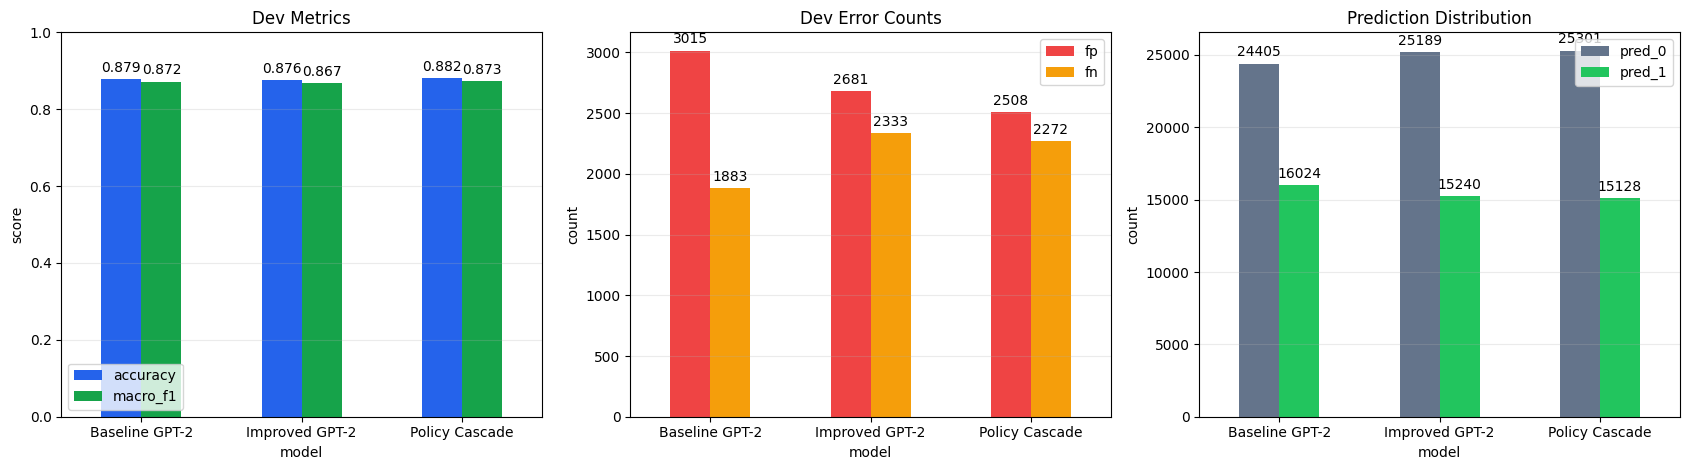

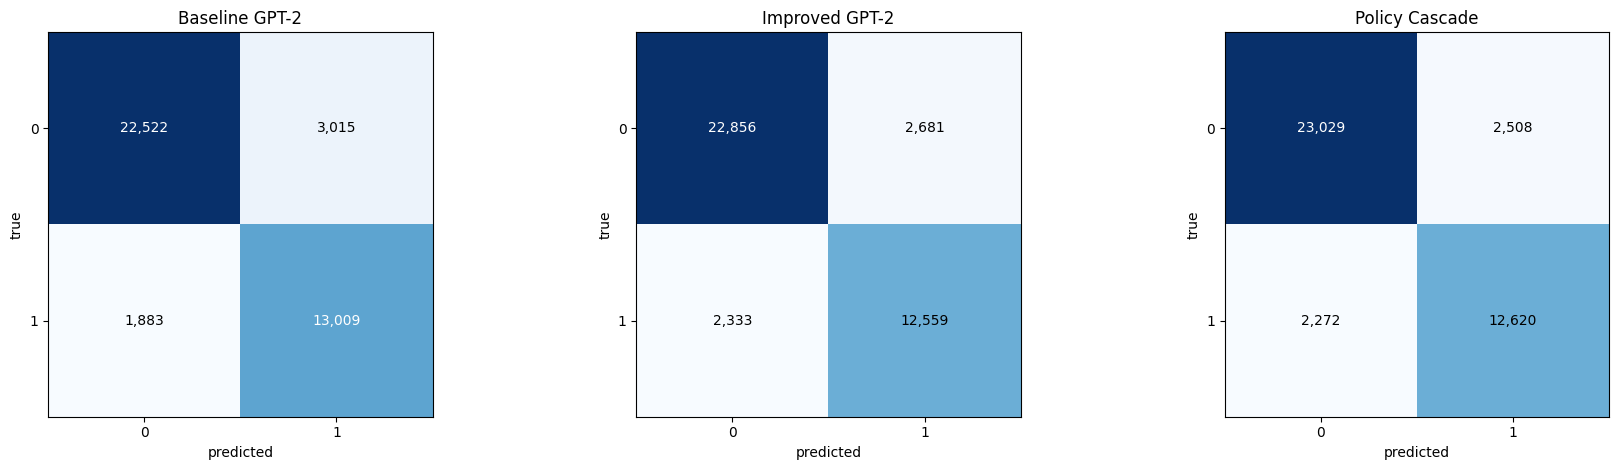

,jaccard_bucket,accuracy,correct,total,model
0,0.0-0.2,0.949930,13622,14340,Baseline GPT-2
1,0.2-0.4,0.840588,10583,12590,Baseline GPT-2
2,0.4-0.6,0.817192,5932,7259,Baseline GPT-2
3,0.6-0.8,0.841690,3307,3929,Baseline GPT-2
4,0.8-1.0,0.903072,2087,2311,Baseline GPT-2
5,0.0-0.2,0.946583,13574,14340,Improved GPT-2
6,0.2-0.4,0.835981,10525,12590,Improved GPT-2
7,0.4-0.6,0.817606,5935,7259,Improved GPT-2
8,0.6-0.8,0.841435,3306,3929,Improved GPT-2
9,0.8-1.0,0.897880,2075,2311,Improved GPT-2


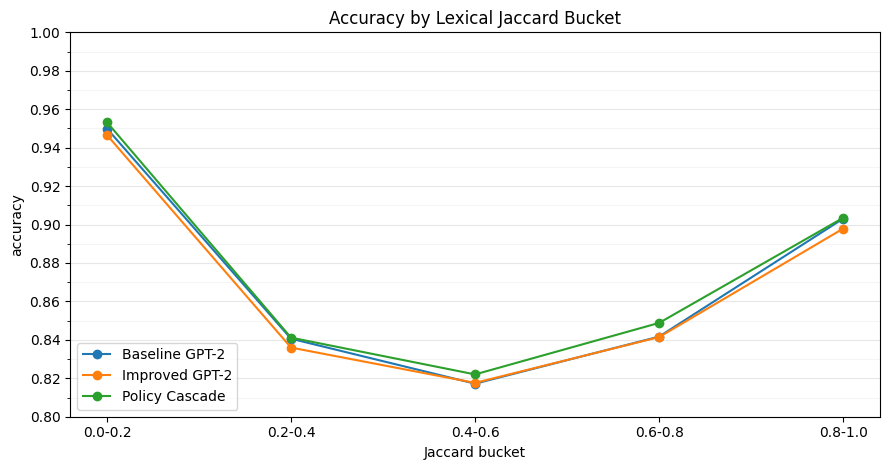

,length_bucket,accuracy,correct,total,model
0,long-long,0.943528,2289,2426,Baseline GPT-2
1,long-medium,0.913126,1913,2095,Baseline GPT-2
2,long-short,0.963687,690,716,Baseline GPT-2
3,medium-long,0.929436,2226,2395,Baseline GPT-2
4,medium-medium,0.873241,10733,12291,Baseline GPT-2
5,medium-short,0.865774,4528,5230,Baseline GPT-2
6,short-long,0.945324,657,695,Baseline GPT-2
7,short-medium,0.858819,4173,4859,Baseline GPT-2
8,short-short,0.855997,8322,9722,Baseline GPT-2
9,long-long,0.945177,2293,2426,Improved GPT-2


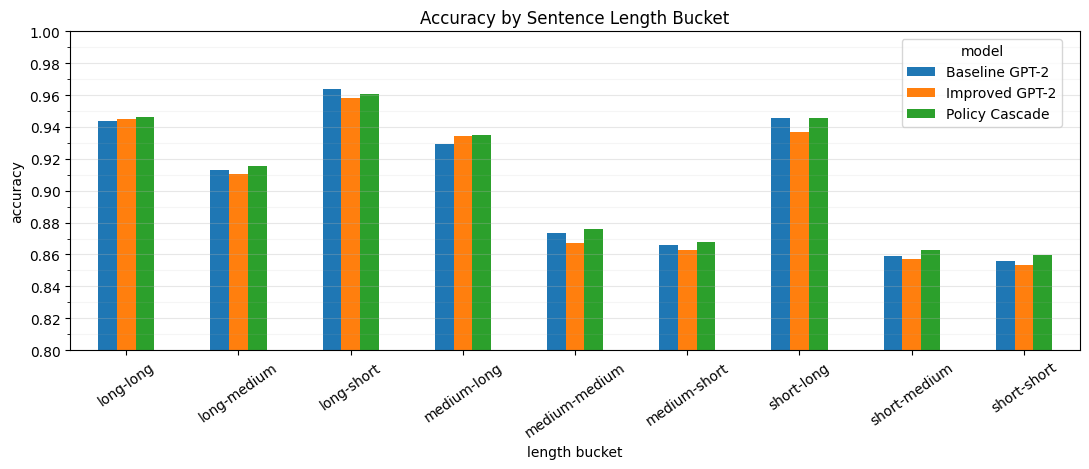

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

metric_df = comparison_df.set_index("model")[["accuracy", "macro_f1"]]
metric_df.plot(kind="bar", ax=axes[0], rot=0, color=["#2563eb", "#16a34a"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Dev Metrics")
axes[0].set_ylabel("score")
axes[0].grid(axis="y", alpha=0.25)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3)

error_df = comparison_df.set_index("model")[["fp", "fn"]]
error_df.plot(kind="bar", ax=axes[1], rot=0, color=["#ef4444", "#f59e0b"])
axes[1].set_title("Dev Error Counts")
axes[1].set_ylabel("count")
axes[1].grid(axis="y", alpha=0.25)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3)

pred_df = comparison_df.set_index("model")[["pred_0", "pred_1"]]
pred_df.plot(kind="bar", ax=axes[2], rot=0, color=["#64748b", "#22c55e"])
axes[2].set_title("Prediction Distribution")
axes[2].set_ylabel("count")
axes[2].grid(axis="y", alpha=0.25)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()


def plot_confusion(ax, matrix, title):
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_xticks([0, 1], labels=["0", "1"])
    ax.set_yticks([0, 1], labels=["0", "1"])
    max_value = max(max(row) for row in matrix)
    for i, row in enumerate(matrix):
        for j, value in enumerate(row):
            color = "white" if value > max_value * 0.55 else "black"
            ax.text(j, i, f"{value:,}", ha="center", va="center", color=color)
    return image

fig, axes = plt.subplots(1, len(evaluation_summaries), figsize=(6 * len(evaluation_summaries), 4.8))
if len(evaluation_summaries) == 1:
    axes = [axes]
for ax, summary in zip(axes, evaluation_summaries):
    plot_confusion(ax, summary["confusion_matrix_rows_true_cols_pred_0_1"], summary["model"])
plt.tight_layout()
plt.show()

bucket_frames = []
for model_name, rows in evaluation_rows.items():
    frame = bucket_accuracy(rows.to_dict("records"), "jaccard_bucket")
    frame["model"] = model_name
    bucket_frames.append(frame)
jaccard_df = pd.concat(bucket_frames, ignore_index=True)
display(jaccard_df)

ACCURACY_YMIN = 0.80
ACCURACY_YMAX = 1.00
ACCURACY_MAJOR_TICKS = [x / 100 for x in range(80, 101, 2)]
ACCURACY_MINOR_TICKS = [x / 100 for x in range(80, 101, 1)]


def tighten_accuracy_axis(ax):
    ax.set_ylim(ACCURACY_YMIN, ACCURACY_YMAX)
    ax.set_yticks(ACCURACY_MAJOR_TICKS)
    ax.set_yticks(ACCURACY_MINOR_TICKS, minor=True)
    ax.grid(axis="y", which="major", alpha=0.30)
    ax.grid(axis="y", which="minor", alpha=0.12)


fig, ax = plt.subplots(figsize=(9, 4.8))
for model_name, frame in jaccard_df.groupby("model"):
    ax.plot(frame["jaccard_bucket"], frame["accuracy"], marker="o", label=model_name)
tighten_accuracy_axis(ax)
ax.set_title("Accuracy by Lexical Jaccard Bucket")
ax.set_xlabel("Jaccard bucket")
ax.set_ylabel("accuracy")
ax.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

length_frames = []
for model_name, rows in evaluation_rows.items():
    frame = bucket_accuracy(rows.to_dict("records"), "length_bucket")
    frame["model"] = model_name
    length_frames.append(frame)
length_df = pd.concat(length_frames, ignore_index=True)
display(length_df)

fig, ax = plt.subplots(figsize=(11, 4.8))
length_pivot = length_df.pivot(index="length_bucket", columns="model", values="accuracy")
length_pivot.plot(kind="bar", ax=ax, rot=35)
tighten_accuracy_axis(ax)
ax.set_title("Accuracy by Sentence Length Bucket")
ax.set_xlabel("length bucket")
ax.set_ylabel("accuracy")
ax.legend(title="model", loc="upper right", bbox_to_anchor=(0.985, 0.985), borderaxespad=0.2)
plt.tight_layout()
plt.show()


## 10. Error Sample 저장

각 모델의 대표 FP/FN 샘플을 저장합니다. 개선 구현이 high-overlap false positive와 low-overlap false negative를 얼마나 줄였는지 정성 분석할 때 사용합니다.


In [12]:
ERROR_DIR = PROJECT_ROOT / "reports" / "paraphrase_comparison"
ERROR_DIR.mkdir(parents=True, exist_ok=True)

saved_error_files = {}
for model_name, rows in evaluation_rows.items():
    errors = rows[rows["error_type"].isin(["FP", "FN"])].copy()
    high_overlap_fp = errors[errors["error_type"].eq("FP")].sort_values("jaccard", ascending=False).head(40)
    low_overlap_fn = errors[errors["error_type"].eq("FN")].sort_values("jaccard", ascending=True).head(40)
    sample = pd.concat([high_overlap_fp, low_overlap_fn], ignore_index=True)
    filename = model_name.lower().replace(" ", "_").replace("-", "_") + "_error_samples.csv"
    out_path = ERROR_DIR / filename
    sample[[
        "error_type", "id", "label", "pred", "jaccard", "length_bucket", "sentence1", "sentence2"
    ]].to_csv(out_path, index=False)
    saved_error_files[model_name] = str(out_path.relative_to(PROJECT_ROOT))

print(json.dumps(saved_error_files, indent=2, ensure_ascii=False))


{
  "Baseline GPT-2": "reports/paraphrase_comparison/baseline_gpt_2_error_samples.csv",
  "Improved GPT-2": "reports/paraphrase_comparison/improved_gpt_2_error_samples.csv",
  "Policy Cascade": "reports/paraphrase_comparison/policy_cascade_error_samples.csv"
}


## 11. 실행 메모

- Baseline: 기존 GPT-2 cloze-style fine-tuning 구현
- Improved: hard/low-overlap example weighting, bidirectional training/evaluation, prompt ensemble, threshold tuning을 적용한 GPT-2 cloze-style fine-tuning 구현
- 최종 제출용 prediction은 선택한 모델의 `para_test_out` 파일을 사용합니다.
